Notebook to test out action parameters in an ad-hoc fashion on the Muller-Brown potential. This notebook is intended to get an intuitive sense for how different constants/actions affect the optimized transition path. For a more rigorous grid search approach, see the mb_tests.py file.

In [1]:
import torch
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

from simpleMB import SimpleMB

import numpy as np
import matplotlib.pyplot as plt


In [2]:
potential = SimpleMB(device = "cuda",n_in=2)

x0, xf = potential.initial_point.detach(), potential.final_point.detach()

In [9]:
from mb_dataset import MBDataset
from mb_calculator import MullerBrownPotential

calculator = MullerBrownPotential(device = "cpu")
dataset = MBDataset(save_path = 'data', timestep = 5.0, temperature = 1000, n_steps = 100000, save_every=100, n_sims = 5)

Running simulations to collect dataest...
Making data


  0%|          | 0/5 [00:00<?, ?it/s]/home/sanjeevr/miniforge3/envs/om-diffusion/lib/python3.12/site-packages/ase/md/md.py:53: FutureWarning: Specify the temperature in K using the 'temperature_K' argument
  warnings.warn(FutureWarning(w))
/home/sanjeevr/miniforge3/envs/om-diffusion/lib/python3.12/site-packages/torch/_functorch/deprecated.py:65: UserWarning: We've integrated functorch into PyTorch. As the final step of the integration, functorch.grad is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use torch.func.grad instead; see the PyTorch 2.0 release notes and/or the torch.func migration guide for more details https://pytorch.org/docs/master/func.migrating.html
  warn_deprecated('grad')
100%|██████████| 5/5 [00:10<00:00,  2.02s/it]


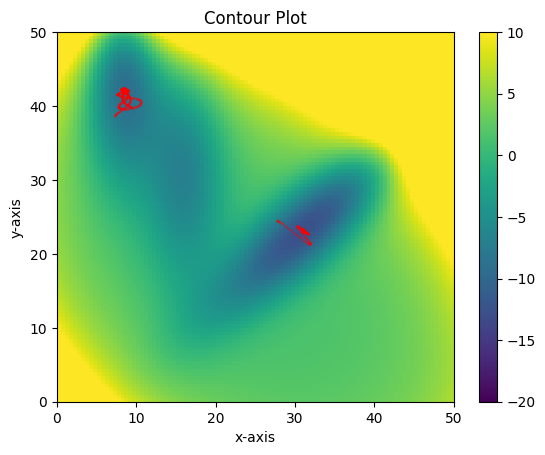

In [10]:
from torch.utils.data import DataLoader
mb_dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

num_points = 100
x_values = torch.linspace(calculator.Lx, calculator.Hx , num_points)
y_values = torch.linspace(calculator.Ly, calculator.Hy, num_points)

x, y = torch.meshgrid(x_values, y_values)
z = calculator.U_split(x, y).cpu()

fig, ax = plt.subplots()
colorbar = ax.imshow(z, extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()), vmin=calculator.U_min, vmax=calculator.U_max, origin='lower', cmap='viridis', aspect='auto')
ax.set(xlabel="x-axis", ylabel="y-axis", title="Contour Plot")
plt.colorbar(colorbar)

# also plot batch from dataloader
for i, batch in enumerate(mb_dataloader):
    ax.scatter(batch[:, 1], batch[:, 0], color='red', s=0.1)

plt.show()



  0%|          | 0/1000 [00:00<?, ?it/s]/home/sanjeevr/mambaforge/envs/om-diffusion/lib/python3.12/site-packages/torch/_functorch/deprecated.py:65: UserWarning: We've integrated functorch into PyTorch. As the final step of the integration, functorch.grad is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use torch.func.grad instead; see the PyTorch 2.0 release notes and/or the torch.func migration guide for more details https://pytorch.org/docs/master/func.migrating.html
  warn_deprecated('grad')
/home/sanjeevr/mambaforge/envs/om-diffusion/lib/python3.12/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/tmp/ipykernel_532956/3130010133.py:69: MatplotlibDeprecationWarning: The tostring_rgb function was deprec

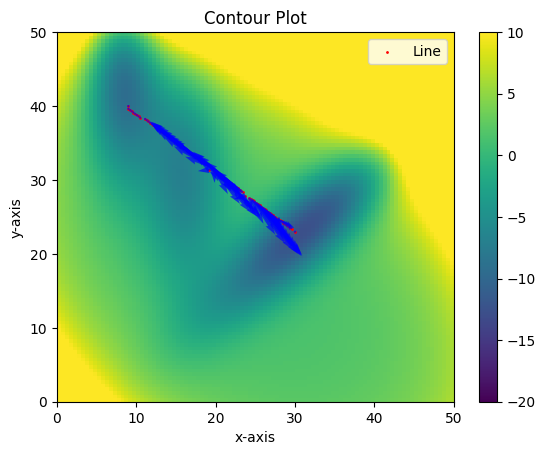

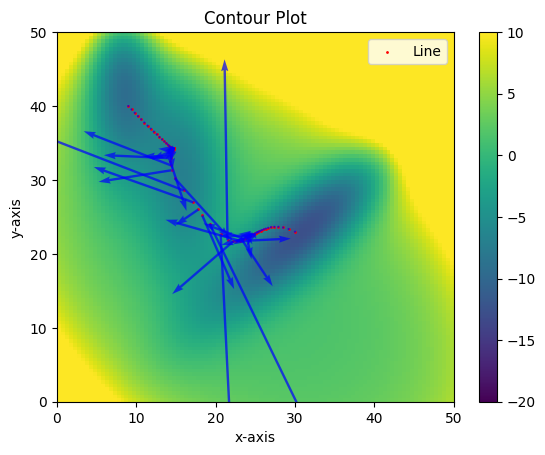

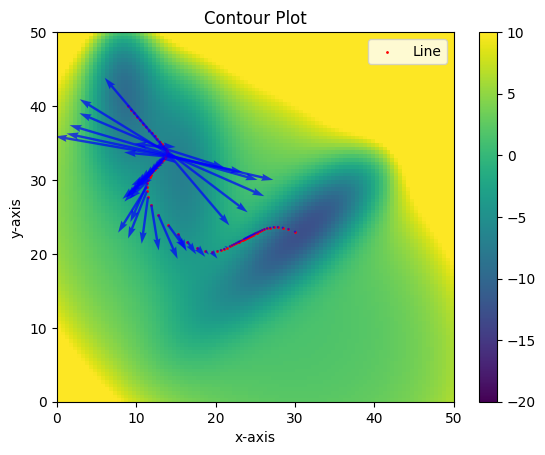

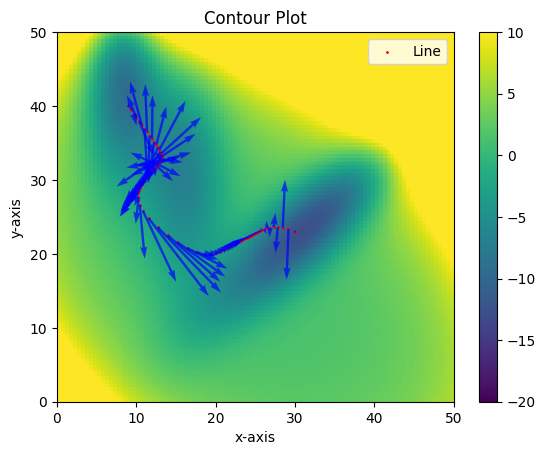

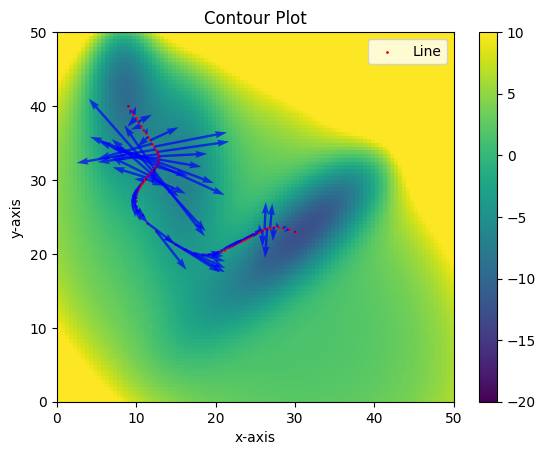

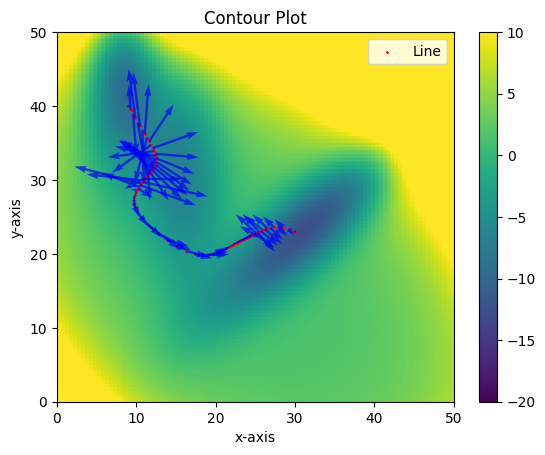

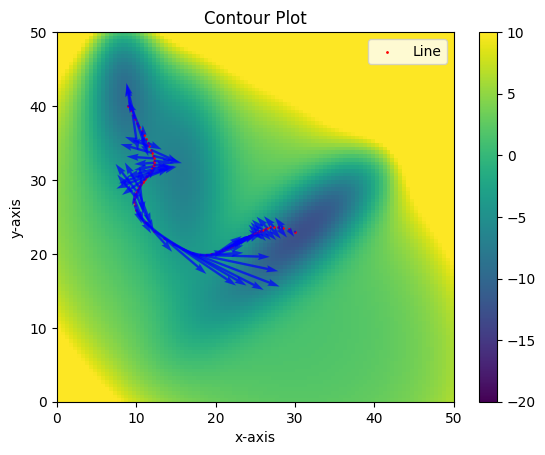

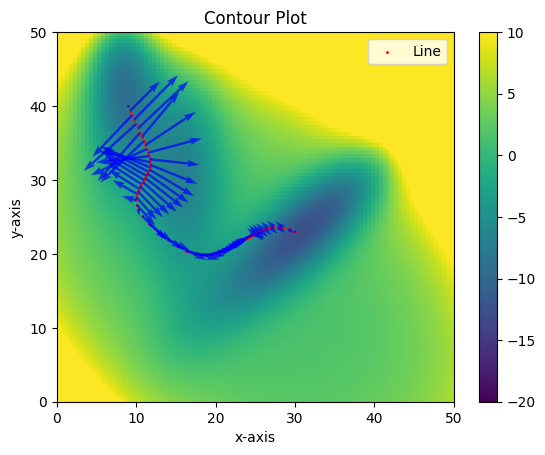

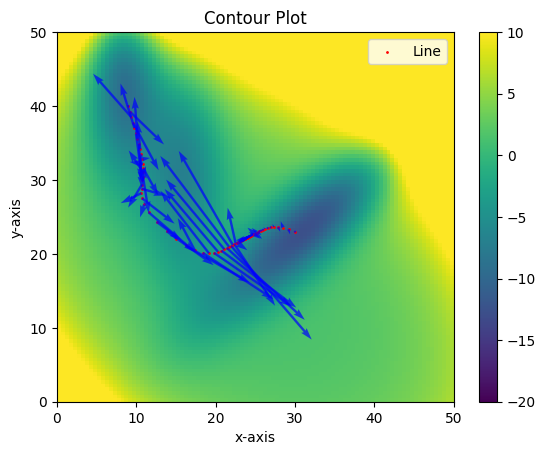

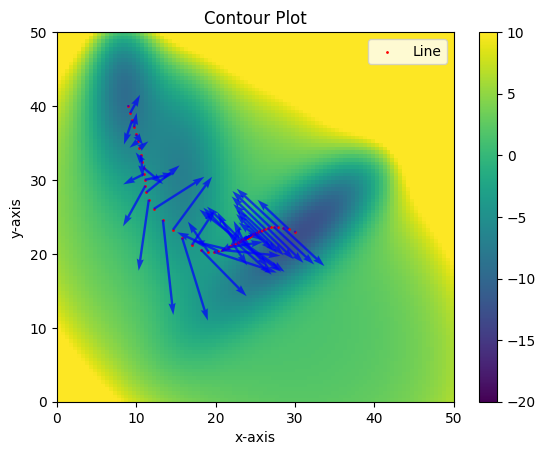

In [4]:
from tqdm import tqdm
import imageio
from mb_actions import SimpleAction, S2Action

"""Optimization Hyperparameters"""

line_density = 100 # path length
dt = 0.1 # time step to use in action
gamma = torch.tensor(0.1) # gamma value to use in action
D = torch.tensor(10) # diffusion coefficient to use in action
#Choose action type
#action_cls = SimpleAction
action_cls = S2Action
action_func = action_cls(potential = potential, dt = dt, gamma = gamma, D = D)

iterations = 1000 # number of optimization steps
alpha = 2e-1 # learning rate
write_every = 100 # how often to write to gif

line_x = torch.linspace(x0[1], xf[1],line_density)
line_y = torch.linspace(x0[0], xf[0], line_density)
line_points = torch.stack((line_x, line_y), axis=-1).to(args.device)

optimizer = torch.optim.Adam([line_points], lr = alpha)

gif_data = []

for i in tqdm(range(iterations)):
    line_points.requires_grad = True
    action = action_func(line_points)

    total_action = action

    optimizer.zero_grad()

    grads, = torch.autograd.grad(total_action, line_points)
    
    with torch.no_grad():
        grads[0,:], grads[-1,:] = torch.zeros(2).to(args.device), torch.zeros(2).to(args.device)
        line_points.grad = grads
        optimizer.step()

        grads = grads.cpu()

        #Calculate the alternative action
        # s_action = simple_action(line_points)

        draw_points = line_points.detach().cpu()

    if i % write_every == 0:
        # print(f"Total action for the step {i} is {(action).cpu().detach().numpy()}")
        num_points = 100
        x_values = torch.linspace(potential.Lx, potential.Hx , num_points)
        y_values = torch.linspace(potential.Ly, potential.Hy, num_points)

        x, y = torch.meshgrid(x_values.to(args.device), y_values.to(args.device))
        z = potential.U_split(x, y).cpu()

        fig, ax = plt.subplots()
        colorbar = ax.imshow(z, extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()), vmin=potential.U_min, vmax=potential.U_max, origin='lower', cmap='viridis', aspect='auto')
        ax.set(xlabel="x-axis", ylabel="y-axis", title="Contour Plot")
        plt.colorbar(colorbar)

        scatter_plot = ax.scatter(draw_points[:,0], draw_points[:,1], s=1, c='red', label='Line')
        quiver_plot = ax.quiver(draw_points[:,0], draw_points[:,1], -grads[:,0], -grads[:,1], scale_units='xy', angles='xy', color='blue', alpha=0.7)
        ax.legend()

        fig.canvas.draw()
        image = np.frombuffer(fig.canvas.tostring_rgb(), dtype="uint8")
        image = image.reshape(
            fig.canvas.get_width_height()[::-1] + (3,)
        )
        gif_data.append(image)

action_str = "S2" if action_func == S2Action else "simple"
imageio.mimsave(f'MB_{action_str}_linedensity={line_density}_gamma={round(gamma.item(), 1)}_dt={round(dt, 1)}_D={round(D.item(), 1)}.gif', gif_data, fps=3)